## Question 1

Find Transition Matrix

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [39]:
sales = pd.read_csv("Sales_data.csv")

# check days is in running order and starts at 1
days = sales['Day']
assert days[0] == 1
assert (days == list(range(1, len(days) + 1))).all()

sales = sales.rename(columns={'Number of cupcakes sold': 'sales'})

sales['sales'].describe()

count    1095.000000
mean       49.507763
std        29.359551
min         1.000000
25%        24.000000
50%        49.000000
75%        75.000000
max       100.000000
Name: sales, dtype: float64

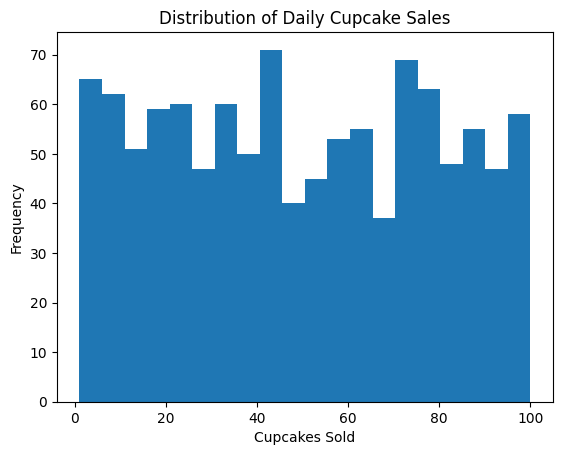

In [40]:

plt.hist(sales['sales'], bins=20)

plt.xlabel("Cupcakes Sold")
plt.ylabel("Frequency")
plt.title("Distribution of Daily Cupcake Sales")

plt.show()

In [34]:
bin = True

if not bin:

    states = sorted(sales['sales'].unique())
    states_arr = np.array(states)

    state_index = {s:i for i,s in enumerate(states)}

    P = np.zeros((len(states), len(states)))

    for t in range(len(sales)-1):
        i = state_index[sales['sales'].iloc[t]]
        j = state_index[sales['sales'].iloc[t+1]]
        P[i,j] += 1

else:
    bins = [0,20,40,60,100]
    labels = ['low','med','high','very_high']

    states_arr = np.array([10,30,50,80])

    sales['state'] = pd.cut(sales['sales'], bins=bins, labels=labels)

    states = labels
    state_index = {s:i for i,s in enumerate(states)}

    P = np.zeros((len(states), len(states)))

    for t in range(len(sales)-1):
        i = state_index[sales['state'].iloc[t]]
        j = state_index[sales['state'].iloc[t+1]]
        P[i,j] += 1

# normalize
P = P / P.sum(axis=1, keepdims=True)

Find Long-run distribution

In [35]:
eigvals, eigvecs = np.linalg.eig(P.T)

pi = eigvecs[:, np.isclose(eigvals,1)]
pi = pi[:,0]

pi = pi / pi.sum()
pi = pi.real

print("Stationary distribution:")
print(pi)

Stationary distribution:
[0.21669963 0.19832886 0.1910661  0.39390541]


Find break-even cupcake price

In [36]:
expected_sales = np.dot(pi, states_arr)

batches = np.ceil(states_arr / 12)
expected_batches = np.dot(pi, batches)

expected_cost = 5 * expected_batches + 100

price = expected_cost / expected_sales

print("Optimal price:", price)

Optimal price: 2.4931942012603647


In [37]:
p = price

sales_vals = sales['sales']

batches = np.ceil(sales_vals / 12)

revenue = p * sales_vals
cost = 5 * batches + 100

profit = revenue - cost
avg_profit = profit.mean()

print("Average profit:", avg_profit)

Average profit: 0.4050692644069702


## Question 2

In [ ]:
import time
from functools import lru_cache

In [ ]:
beta = 1 / 1.05
T_small = 3
T_big = 100

# Markov chain for daily price changes
# states: 0 = same, 1 = up, 2 = down
P = np.array([
    [0.1, 0.45, 0.45],
    [0.2, 0.2, 0.6],
    [0.1, 0.7, 0.2]
], dtype=float)

# price change mapping
delta = {
    0: 0,    # same
    1: 10,   # up
    2: -10   # down
}

ACTIONS = ["buy_stock", "buy_future", "short_stock", "do_nothing"]

In [ ]:
# TODO

## Question 3

In [38]:
X = np.array([
    [1.0, 10.0],
    [2.0, 15.0],
    [3.0, 20.0],
    [4.0, 25.0]
])

y = np.array([18.0, 35.0, 65.0, 110.0])

# =========================
# Model
# f_theta(x) = theta1 * tanh(theta2 * x1) + theta3 * (x2)^2
# =========================
def f_theta(x, theta):
    x1, x2 = x
    theta1, theta2, theta3 = theta
    return theta1 * np.tanh(theta2 * x1) + theta3 * (x2 ** 2)

def loss(theta, X, y):
    preds = np.array([f_theta(x, theta) for x in X])
    return np.mean((y - preds) ** 2)

# =========================
# Gradient of single-sample loss
# ell_i(theta) = (y_i - f_theta(x_i))^2
# =========================
def grad_single(theta, x, y_true):
    x1, x2 = x
    theta1, theta2, theta3 = theta

    z = theta2 * x1
    tanh_z = np.tanh(z)
    pred = theta1 * tanh_z + theta3 * (x2 ** 2)
    e = y_true - pred

    d_theta1 = -2 * e * tanh_z
    d_theta2 = -2 * e * theta1 * (1 - tanh_z**2) * x1
    d_theta3 = -2 * e * (x2 ** 2)

    return np.array([d_theta1, d_theta2, d_theta3])

# =========================
# SGD
# =========================
def sgd(X, y, theta0, lr=1e-4, epochs=20000, seed=42):
    rng = np.random.default_rng(seed)
    theta = theta0.astype(float).copy()
    history = []

    n = len(y)

    for epoch in range(epochs):
        indices = np.arange(n)
        rng.shuffle(indices)

        for i in indices:
            grad = grad_single(theta, X[i], y[i])
            theta -= lr * grad

        history.append(loss(theta, X, y))

    return theta, history

# =========================
# Run SGD
# =========================
theta0 = np.array([1.0, 0.1, 0.1])

theta_star, history = sgd(
    X, y, theta0,
    lr=1e-4,
    epochs=20000,
    seed=42
)

print("Estimated theta* =", theta_star)
print("Final loss =", loss(theta_star, X, y))

print("\nPredictions:")
for i in range(len(X)):
    pred = f_theta(X[i], theta_star)
    print(f"i={i+1}, x={X[i]}, y={y[i]:.4f}, prediction={pred:.4f}")

C:\Users\rachm\AppData\Local\Temp\ipykernel_17560\2172006134.py:21: RuntimeWarning: overflow encountered in square
  return np.mean((y - preds) ** 2)
C:\Users\rachm\AppData\Local\Temp\ipykernel_17560\2172006134.py:37: RuntimeWarning: overflow encountered in scalar multiply
  d_theta2 = -2 * e * theta1 * (1 - tanh_z**2) * x1
C:\Users\rachm\AppData\Local\Temp\ipykernel_17560\2172006134.py:37: RuntimeWarning: invalid value encountered in scalar multiply
  d_theta2 = -2 * e * theta1 * (1 - tanh_z**2) * x1


Estimated theta* = [nan nan nan]
Final loss = nan

Predictions:
i=1, x=[ 1. 10.], y=18.0000, prediction=nan
i=2, x=[ 2. 15.], y=35.0000, prediction=nan
i=3, x=[ 3. 20.], y=65.0000, prediction=nan
i=4, x=[ 4. 25.], y=110.0000, prediction=nan
